In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datascience import *
%matplotlib inline
plt.style.use('fivethirtyeight')

## I/ Tinh SD

In [2]:
any_numbers = make_array(1,2,3,4,5,6)
np.std(any_numbers)

1.707825127659933

In [3]:
nba2013 = Table.read_table('../../Data/nba2013.csv')
nba2013

Name,Position,Height,Weight,Age
DeQuan Jones,Guard,80,221,23
Darius Miller,Guard,80,235,23
Trevor Ariza,Guard,80,210,28
James Jones,Guard,80,215,32
Wesley Johnson,Guard,79,215,26
Klay Thompson,Guard,79,205,23
Thabo Sefolosha,Guard,79,215,29
Chase Budinger,Guard,79,218,25
Kevin Martin,Guard,79,185,30
Evan Fournier,Guard,79,206,20


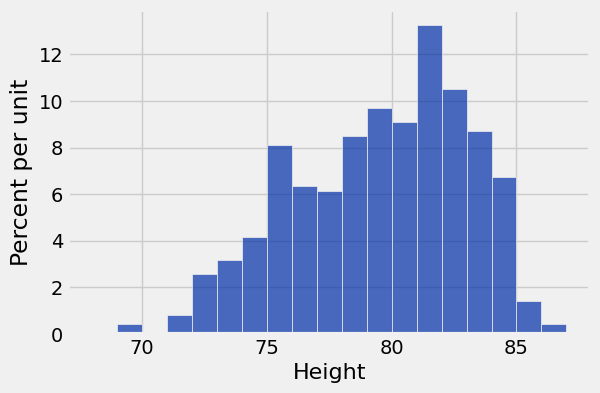

In [4]:
nba2013.hist('Height',bins = np.arange(68,88,1))

In [5]:
mean_height = np.mean(nba2013.column('Height'))
mean_height

79.065346534653472

In [6]:
std_height = np.std(nba2013.column('Height'))
std_height

3.4505971830275546

In [7]:
nba2013.sort('Height', descending=True)

Name,Position,Height,Weight,Age
Hasheem Thabeet,Center,87,263,26
Roy Hibbert,Center,86,278,26
Alex Len,Center,85,255,20
Rudy Gobert,Center,85,235,21
Meyers Leonard,Center,85,250,21
Timofey Mozgov,Center,85,250,27
Marc Gasol,Center,85,265,28
Spencer Hawes,Center,85,245,25
Tyson Chandler,Center,85,235,30
Pau Gasol,Forward,84,250,33


In [8]:
(87-mean_height)/std_height

2.2995015194397923

In [9]:
nba2013.sort('Height', descending = False)

Name,Position,Height,Weight,Age
Isaiah Thomas,Guard,69,185,24
Nate Robinson,Guard,69,180,29
John Lucas III,Guard,71,157,30
Ty Lawson,Guard,71,195,25
Shane Larkin,Guard,71,176,20
Phil Pressey,Guard,71,175,22
Ish Smith,Guard,72,175,25
Chris Paul,Guard,72,175,28
Darren Collison,Guard,72,160,26
J.J. Barea,Guard,72,175,29


In [10]:
(69-mean_height)/std_height

-2.9169868288775844

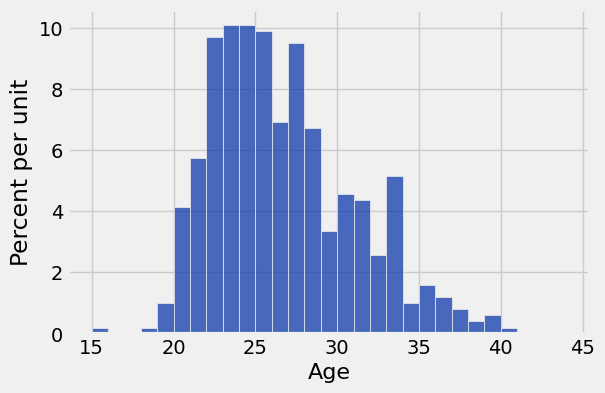

In [11]:
nba2013.hist('Age',bins = np.arange(15,45,1))

In [12]:
mean_age = np.mean(nba2013.column('Age'))
std_age = np.std(nba2013.column('Age'))
print(mean_age)
std_age

26.1900990099


4.3212004417203067

In [13]:
(np.max(nba2013.column('Age')) - mean_age)/std_age

3.1958482778922357

In [14]:
(np.min(nba2013.column('Age')) - mean_age)/std_age

-2.5895811038670811

## II/ Don vi chuan

In [15]:
def standard_units(numbers_array):   
    return (numbers_array-np.mean(numbers_array))/np.std(numbers_array)


In [16]:
united = Table().read_table('../../Data/united_summer2015.csv')
united

Date,Flight Number,Destination,Delay
6/1/15,73,HNL,257
6/1/15,217,EWR,28
6/1/15,237,STL,-3
6/1/15,250,SAN,0
6/1/15,267,PHL,64
6/1/15,273,SEA,-6
6/1/15,278,SEA,-8
6/1/15,292,EWR,12
6/1/15,300,HNL,20
6/1/15,317,IND,-10


In [17]:
united = united.with_column(
    'Delay (Standard_units)',standard_units(united.column('Delay'))
)
united

Date,Flight Number,Destination,Delay,Delay (Standard_units)
6/1/15,73,HNL,257,6.08766
6/1/15,217,EWR,28,0.287279
6/1/15,237,STL,-3,-0.497924
6/1/15,250,SAN,0,-0.421937
6/1/15,267,PHL,64,1.19913
6/1/15,273,SEA,-6,-0.573912
6/1/15,278,SEA,-8,-0.62457
6/1/15,292,EWR,12,-0.117987
6/1/15,300,HNL,20,0.0846461
6/1/15,317,IND,-10,-0.675228


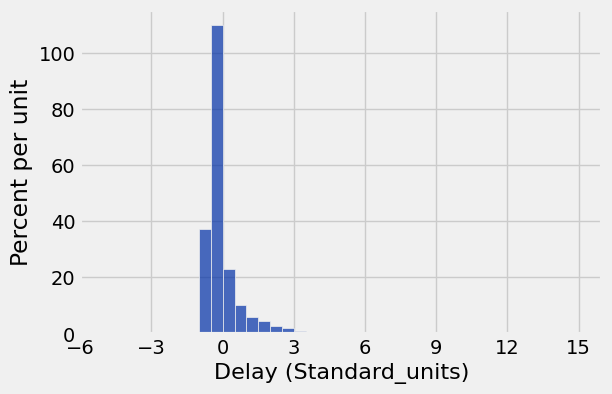

In [18]:
united.hist('Delay (Standard_units)', bins=np.arange(-5, 15.5, 0.5))
plt.xticks(np.arange(-6, 17, 3));

In [19]:
print('hello world')

hello world


# Ham phan phoi tich luy chuan cdf

In [20]:
from scipy import stats

In [21]:
stats.norm.cdf(1)

0.84134474606854293

In [22]:
stats.norm.cdf(2) - stats.norm.cdf(-2)

0.95449973610364158

In [23]:
1 -  stats.norm.cdf(1)

0.15865525393145707

In [24]:
united

Date,Flight Number,Destination,Delay,Delay (Standard_units)
6/1/15,73,HNL,257,6.08766
6/1/15,217,EWR,28,0.287279
6/1/15,237,STL,-3,-0.497924
6/1/15,250,SAN,0,-0.421937
6/1/15,267,PHL,64,1.19913
6/1/15,273,SEA,-6,-0.573912
6/1/15,278,SEA,-8,-0.62457
6/1/15,292,EWR,12,-0.117987
6/1/15,300,HNL,20,0.0846461
6/1/15,317,IND,-10,-0.675228


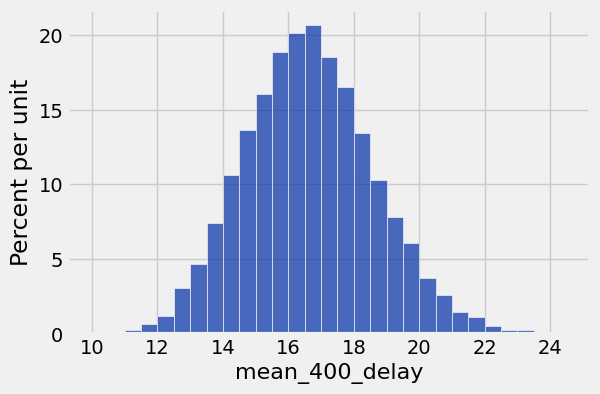

In [25]:
repitition = 10000
delay_array = make_array()

for i in np.arange(repitition):
    united_delay = united.sample(400) 
    delay_array = np.append(delay_array,np.mean(united_delay.column('Delay')))
result = Table().with_column(
    'mean_400_delay', delay_array
)      
result.hist(bins = np.arange(10,25,0.5))

# Giai thich dinh ly gioi han trung tam bang mo phong ti le hoa mau tim

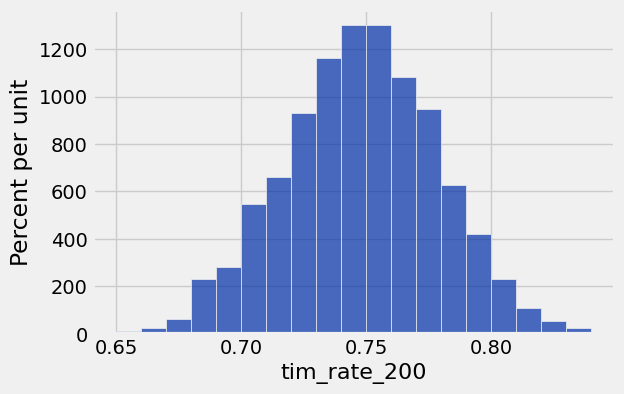

In [26]:
sample1 = [0.75,0.25]
result = make_array()
for i in np.arange(repitition):
    sample2 = sample_proportions(200,sample1)
    result = np.append(result,sample2.item(0))
result1 = Table().with_column(
    'tim_rate_200',result
)
result1.hist(bins=np.arange(0.65, 0.85, 0.01))
    

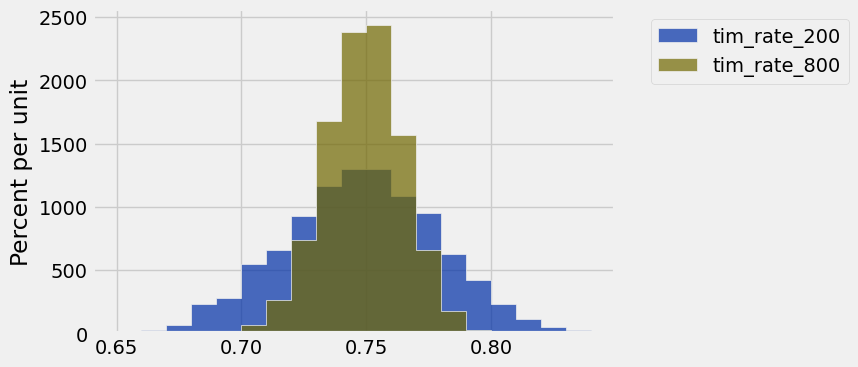

In [27]:
props = make_array()
for i in np.arange(repitition):
    prop_sample = sample_proportions(800,sample1)
    props = np.append(props,prop_sample.item(0))
result1 = result1.with_column(
    'tim_rate_800', props
)
result1.hist(bins=np.arange(0.65, 0.85, 0.01))

Bài toán: Tìm tỉ lệ cử tri bầu cử cho một ứng cử viên A với khoảng tin cậy 95% và độ chính xác là độ rộng của khoảng tin cậy không quá 1%

Ta phải đi ước lượng độ lệch chuẩn của quần thể để xác định kích thức mẫu phù hợp

Proportion of 1 | sd
0.1             | 0.3
0.2             | 0.4
0.3             | 0.458258
0.4             | 0.489898
0.5             | 0.5
0.6             | 0.489898
0.7             | 0.458258
0.8             | 0.4
0.9             | 0.3


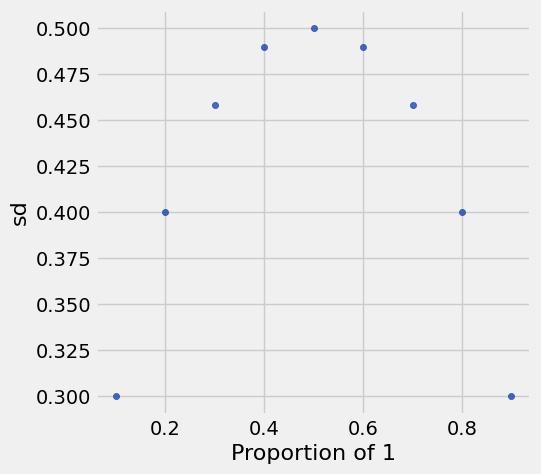

In [28]:
sd_array = make_array()
for i in np.arange(1,10,1):
    sample = np.append(np.ones(i),1 - np.ones(10-i))
    sd_array = np.append(sd_array,np.std(sample))
result = Table().with_columns(
    'Proportion of 1', np.arange(0.1,1,0.1),
    'sd', sd_array
)
print(result)
result.scatter('Proportion of 1','sd')

Ta thấy độ lệch chuẩn max là 0.5 từ đó suy ra được kích thước mẫu tối thiểu là...